In [3]:
import pandas as pd
import requests

In [4]:

# 2024 CPS ASEC (March Supplement) Endpoint
url = "https://api.census.gov/data/2024/cps/asec/mar"

# The variables for the analysis:
# WSAL_VAL = Total wage and salary
# HRSWK = Hours worked per week
# NOEMP = Employer size category
# GTCBSA = Metropolitan Statistical Area code (for the cost-of-living merge later)
# A_DTOCC = Detailed occupation code
variables = "WSAL_VAL,HRSWK,NOEMP,GTCBSA,OCCUP"

params = {
    "get": variables,
    "for": "state:*"}


# Fetch the data
response = requests.get(url, params=params)
data = response.json()

# The first list in the JSON response contains our column headers
asec_data = pd.DataFrame(data[1:], columns=data[0])

# Convert the numeric columns from strings to actual numbers
cols_to_convert = ['WSAL_VAL', 'HRSWK', 'NOEMP', 'OCCUP']
asec_data[cols_to_convert] = asec_data[cols_to_convert].apply(pd.to_numeric, errors='coerce')



In [5]:
rpp_data = pd.read_csv("RPP.csv", skiprows=3, skipfooter=5)

C:\Users\samho\AppData\Local\Temp\ipykernel_4680\655116147.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  rpp_data = pd.read_csv("RPP.csv", skiprows=3, skipfooter=5)


In [6]:
# GTCBSA and GeoFIPS are the same in either table. Let's merge them,
# but first we need to make sure they are int type.
asec_data['GTCBSA'] = asec_data['GTCBSA'].astype(int)
rpp_data['GeoFIPS'] = rpp_data['GeoFIPS'].astype(int)

df_merged = pd.merge(
    asec_data,
    rpp_data,
    left_on='GTCBSA',
    right_on='GeoFIPS',
    how='inner'
)

In [7]:
# Now that we have the cost of living multiplier for each location, we can make a
# cost-of-living adjusted salary.

# First we need to make sure they are float type
df_merged['WSAL_VAL'] = asec_data['WSAL_VAL'].astype(float)
df_merged['2024'] = df_merged['2024'].astype(float)

df_merged['col_adj_salary'] = df_merged['WSAL_VAL'] / (df_merged['2024'] / 100)

In [8]:
# So, the data is about ready to visualize. We are only interested in four columns here:
# hours worked per week (HRSWK), salary adjusted for cost of living, company size (NOEMP),
# and occupation (OCCUP).

# To keep this digestable, let's just focus on three different occupations:
# Data Scientist, Accountant, and Warehouse Worker

# Make sure A_DTOCC and NOEMP are int data types
df_merged['OCCUP'] = df_merged['OCCUP'].astype(int)
df_merged['NOEMP'] = df_merged['NOEMP'].astype(int)

# Create the three distinct groups
df_wh = df_merged[df_merged['OCCUP'] == 9620].copy()
df_acct = df_merged[df_merged['OCCUP'] == 800].copy()

# Combine Data Scientists (1240) and Software Developers (1021)
tech_codes = [1240, 1021]
df_tech = df_merged[df_merged['OCCUP'].isin(tech_codes)].copy()

# Rename the label so your plot title looks clean
df_tech['Job_Title'] = 'Software & Data Professionals'
df_acct['Job_Title'] = 'Accountant'
df_wh['Job_Title'] = 'Warehouse Worker'

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def make_plot_for_occupation(df, job_title):
    # 1. Clean data, drop ghosts/NIU, and add jitter
    df_clean = df[(df['col_adj_salary'] > 20000) & (df['NOEMP'] > 0)].copy()
    df_clean['HRSWK_jitter'] = df_clean['HRSWK'] + np.random.uniform(-1.5, 1.5, size=len(df_clean))
    
    # 2. Use your custome BTT style for plotting
    plt.style.use(['Solarize_Light2', 'btt_style'])
    fig, ax = plt.subplots(figsize=(11, 7))
    
    # 3. Setup categories for discrete legend
    labels = ['Under 10', '10 - 24', '25 - 99', '100 - 499', '500 - 999', '1,000+']
    colors = plt.cm.viridis(np.linspace(0, 1, len(labels)))
    
    # 4. Generate the scatter using a loop for discrete legend entries
    for i, label in enumerate(labels):
        census_code = i + 1
        subset = df_clean[df_clean['NOEMP'] == census_code]
        ax.scatter(subset['HRSWK_jitter'], 
                   subset['col_adj_salary'], 
                   color=colors[i], 
                   label=label,
                   s=80, alpha=0.6, edgecolors='black', linewidth=0.7)
    
    # 5. Tick parameters and axis limits (Fixed to your 20pt mobile optimization)
    ax.tick_params(axis='x', which='major', length=8, width=1.5, labelsize=20)
    ax.tick_params(axis='y', which='major', length=8, width=1.5, labelsize=20)
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
    ax.set_xlim(0,80)
    ax.set_ylim(0,400000)
    
    # 6. Titles and Labels (Fixed to your 30pt and 24pt optimization)
    ax.set_title(job_title, fontsize=30, fontweight='bold', loc='center', pad=20)
    ax.set_xlabel('Hours Worked Per Week', fontsize=24, fontweight='semibold')
    ax.set_ylabel('Adjusted Annual Salary', fontsize=24, fontweight='semibold')
    
    # 7. Legend on the right (bbox_to_anchor keeps it outside the plot)
    # Using 20pt for legend text to match your tick sizes
    leg = ax.legend(title="Company Size", 
                    title_fontsize=24, 
                    fontsize=20, 
                    loc='center left', 
                    bbox_to_anchor=(1, 0.5),
                    frameon=True,
                    facecolor='white',
                    edgecolor='lightgray')
    leg.get_title().set_fontweight('bold')
    
    # 8. Sample Size Annotation (Fixed to your 20pt size)
    n_count = len(df_clean)
    ax.text(0.95, 0.95, f'n = {n_count}', 
            transform=ax.transAxes, fontsize=20, fontweight='bold',
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='lightgray', boxstyle='round,pad=0.4'))
            
    fig.tight_layout()
    fig.savefig(f"{job_title}.png")

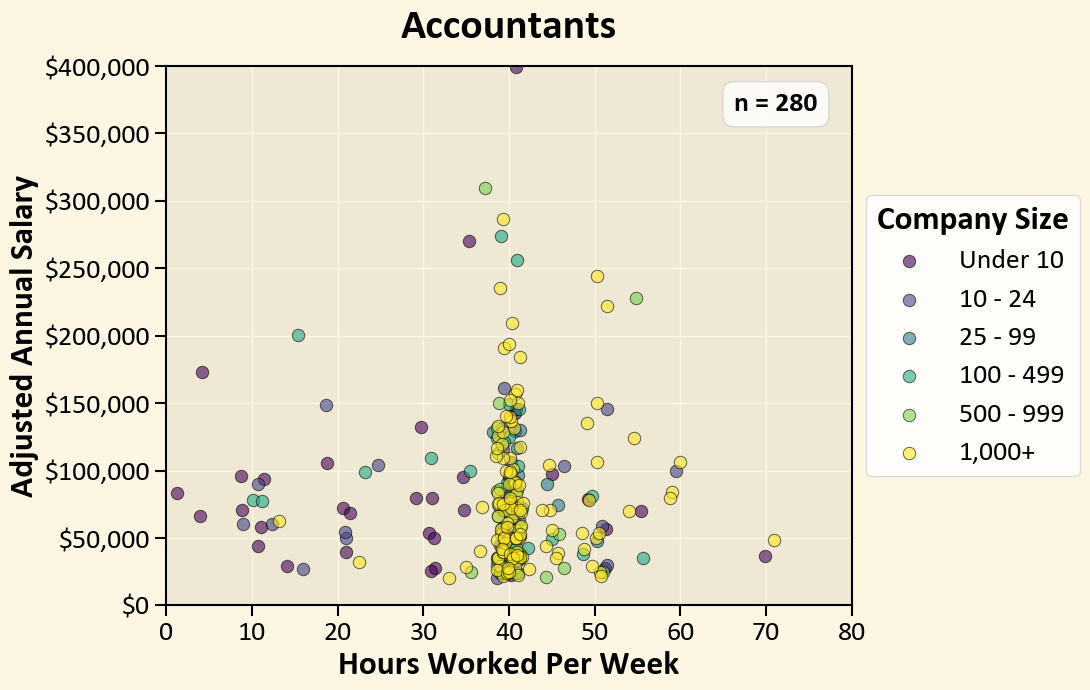

In [10]:
make_plot_for_occupation(df_acct, "Accountants")


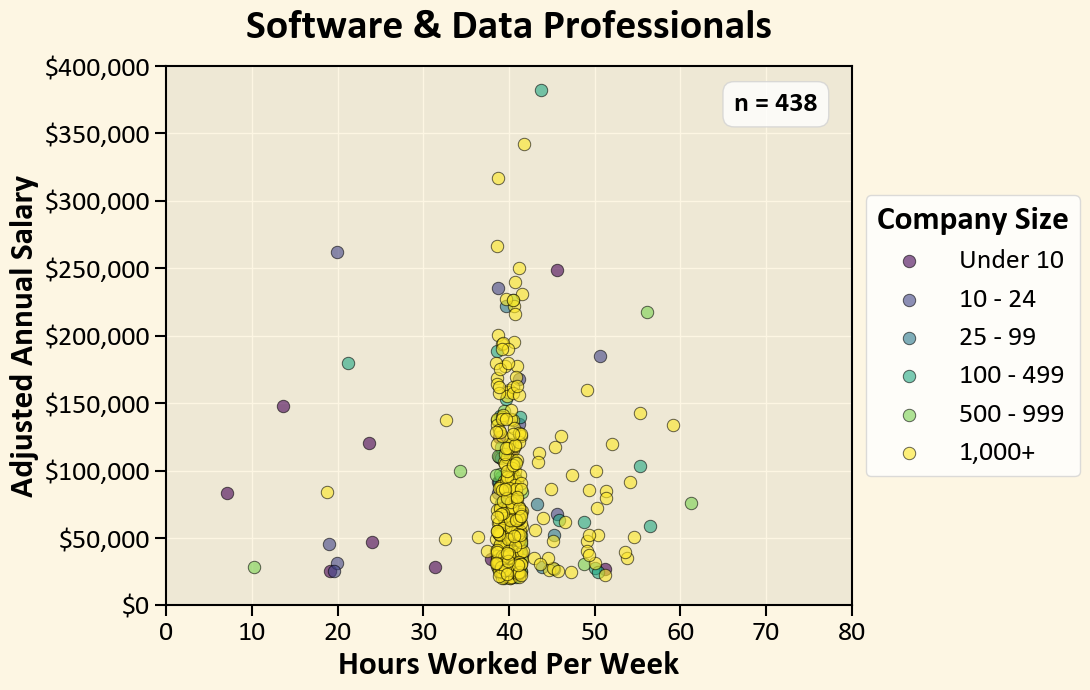

In [11]:
make_plot_for_occupation(df_tech,"Software & Data Professionals")

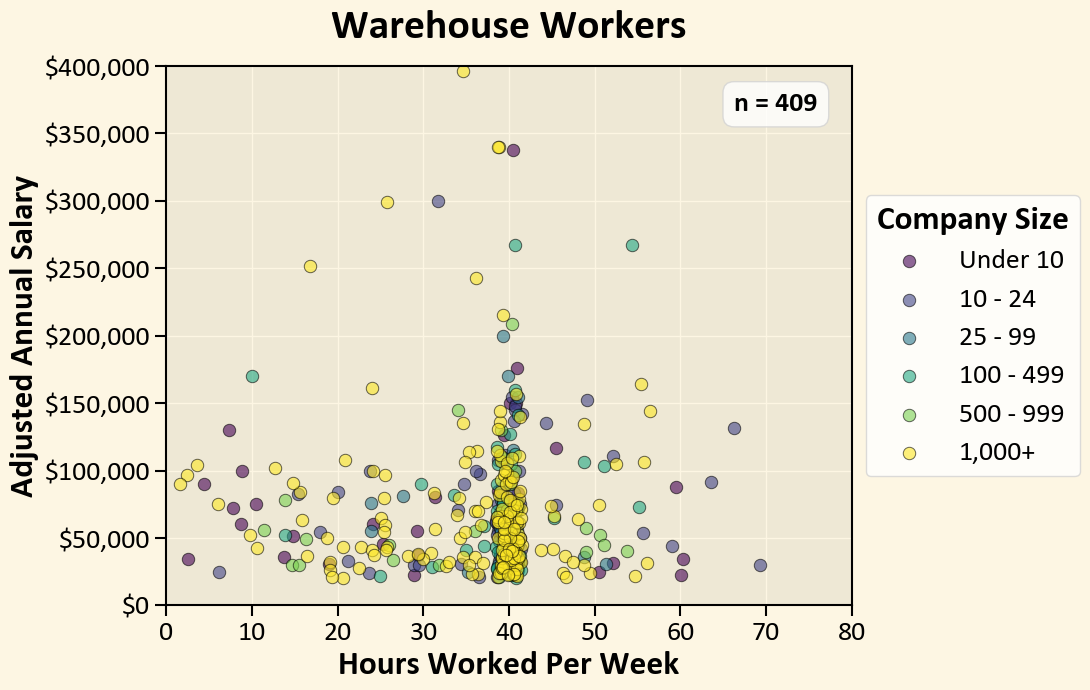

In [12]:
make_plot_for_occupation(df_wh,"Warehouse Workers")

In [13]:
def get_iqr_metrics(df, job_title):
    # Filter into our two extremes
    small_biz = df[df['NOEMP'].isin([1, 2])]
    big_biz = df[df['NOEMP'] == 6]
    
    # Calculate IQR for Hours Worked
    hrs_iqr_small = small_biz['HRSWK'].quantile(0.75) - small_biz['HRSWK'].quantile(0.25)
    hrs_iqr_big = big_biz['HRSWK'].quantile(0.75) - big_biz['HRSWK'].quantile(0.25)
    
    # Calculate IQR for Adjusted Salary
    sal_iqr_small = small_biz['col_adj_salary'].quantile(0.75) - small_biz['col_adj_salary'].quantile(0.25)
    sal_iqr_big = big_biz['col_adj_salary'].quantile(0.75) - big_biz['col_adj_salary'].quantile(0.25)
    
    return {
        "Occupation": job_title,
        "Hours IQR (Small Biz)": hrs_iqr_small,
        "Hours IQR (Big Corp)": hrs_iqr_big,
        "Salary IQR (Small Biz)": f"${sal_iqr_small:,.0f}",
        "Salary IQR (Big Corp)": f"${sal_iqr_big:,.0f}"
    }

# Run it for all three dataframes
results = [
    get_iqr_metrics(df_wh, "Warehouse Workers"),
    get_iqr_metrics(df_acct, "Accountants"),
    get_iqr_metrics(df_tech, "Software & Data Professionals")
]

# Throw it into a clean dataframe to view the final table
summary_table = pd.DataFrame(results)
display(summary_table)

,Occupation,Hours IQR (Small Biz),Hours IQR (Big Corp),Salary IQR (Small Biz),Salary IQR (Big Corp)
0,Warehouse Workers,6.5,8.0,"$51,935","$41,115"
1,Accountants,5.5,0.0,"$47,486","$50,215"
2,Software & Data Professionals,0.0,0.0,"$45,297","$52,550"


In [14]:
# For this narrative, reporting the IQR for salaries is just over-
# complicating things. Just leave it out when you publish. The hours
# worked is the real story you're after.

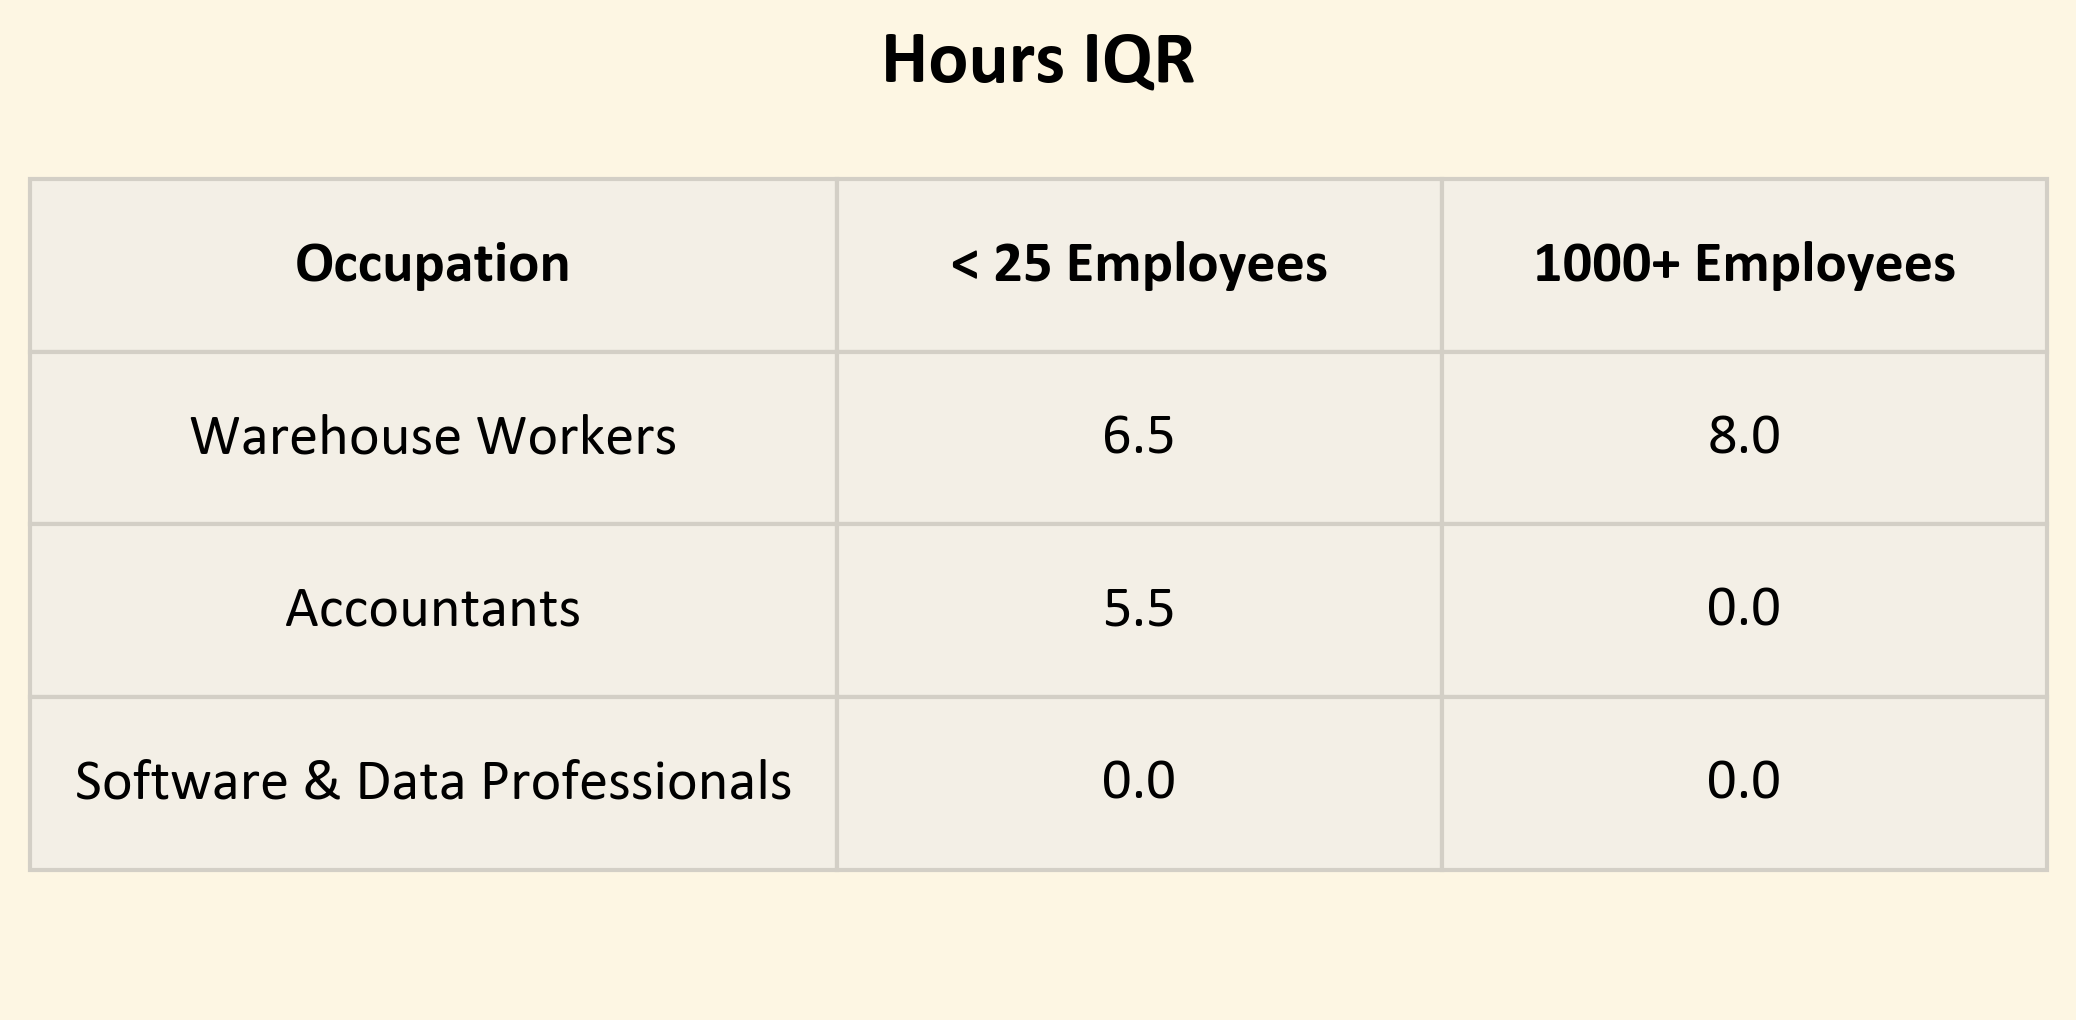

In [15]:
import matplotlib.pyplot as plt

# 1. Shorter canvas to eliminate dead vertical space for a single table
fig, ax = plt.subplots(figsize=(7, 3.5), dpi=300)
ax.axis('off') 

# 2. Extract only the hours data
hours_data = summary_table[['Occupation', 'Hours IQR (Small Biz)', 'Hours IQR (Big Corp)']].values

mobile_headers = ["Occupation", "< 25 Employees", "1000+ Employees"]

# 3. Draw the table
table_hours = ax.table(
    cellText=hours_data, colLabels=mobile_headers,
    loc='center', cellLoc='center', colWidths=[0.4, 0.3, 0.3]
)

# 4. Use 'pad' to add clean spacing above the table
ax.set_title("Hours IQR", weight='bold', size=18, y=.95)

# 5. Apply Typography and Colors
btt_bg_color = '#F3EFE6' 

table_hours.auto_set_font_size(False)
table_hours.set_fontsize(14) 
table_hours.scale(1, 3) 

for (row, col), cell in table_hours.get_celld().items():
    cell.set_facecolor(btt_bg_color) 
    cell.set_edgecolor('#D3CFC6') 
    cell.set_text_props(ha='center')
    
    if row == 0: 
        cell.set_text_props(weight='bold')

plt.tight_layout(pad=1.0) 
plt.savefig('btt_mobile_hours_iqr.png', bbox_inches='tight')